**Role: the 20-minute introduction.** The shortest complete pass through a calibration cycle, with every step linked to the concept chapter behind it. For the full lifecycle — monitoring, actions, and every artifact serialized — see [Full lifecycle on a rare-event portfolio](../pd_end_to_end/).

# PD calibration walkthrough

A full probcal cycle on a synthetic credit-risk portfolio: **diagnose → select → fit → re-anchor → backtest → translate thresholds**. Every step links to the concept chapter that explains it.

The portfolio is deliberately miscalibrated the way low-default portfolios are in practice: a spread error plus an asymmetric low-PD tail distortion, at a ~3% event rate.

In [1]:
import numpy as np

from probcal import (
    BetaCalibrator,
    CalibratorSelector,
    LogitOffset,
    make_pd_portfolio,
)
from probcal.metrics import calibration_guardrails, evaluate, jeffreys_grade_test

port = make_pd_portfolio(n=4000, random_state=42)
s, y = port.scores, port.y
print(f'portfolio: n={len(s)}, defaults={int(y.sum())}, mean score={s.mean():.4f}, '
      f'realized rate={y.mean():.4f}')

portfolio: n=4000, defaults=114, mean score=0.0613, realized rate=0.0285


## 1. Diagnose

The guardrail triplet (slope, intercept, Spiegelhalter) localizes the defect; see [Metrics and tests](../../concepts/metrics/).

In [2]:
g = calibration_guardrails(y, s)
print(f'slope     {g.slope:+.3f}   ok={g.slope_ok}')
print(f'intercept {g.intercept:+.3f}   ok={g.intercept_ok}')
print(f'spiegelhalter p {g.spiegelhalter_p:.4f}   ok={g.spiegelhalter_ok}')

slope     +0.725   ok=False
intercept -0.856   ok=False
spiegelhalter p 0.0000   ok=False


The logit-scale reliability diagram is the recommended view for low-PD work — the low-probability region gets the resolution the decisions need ([Visualization](../../concepts/visualization/)).

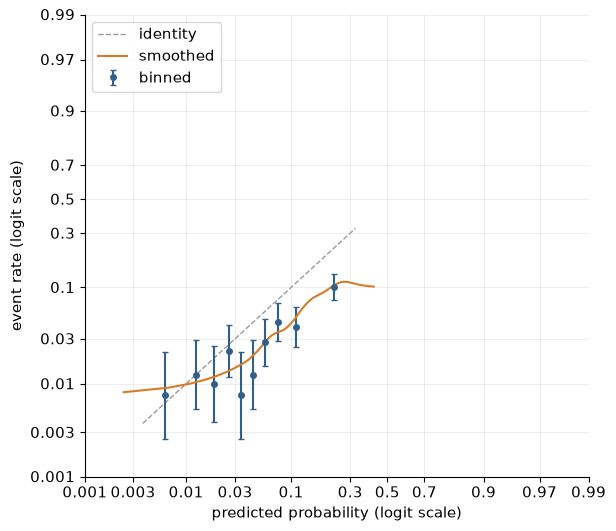

In [3]:
import matplotlib.pyplot as plt

from probcal import reliability_binned, reliability_loess
from probcal.plots import plot_reliability

plot_reliability(reliability_binned(y, s), smooth=reliability_loess(y, s), scale='logit')
plt.show()

## 2. Select

`CalibratorSelector` compares candidates by out-of-fold log loss — never on their own fitting data ([Automatic selection](../../concepts/auto-selection/)). A restricted menu keeps this demo fast.

In [4]:
from probcal import CenteredIsotonicCalibrator, PlattCalibrator, TemperatureCalibrator

sel = CalibratorSelector(
    candidates={
        'platt': PlattCalibrator(),
        'temperature': TemperatureCalibrator(),
        'beta_abm': BetaCalibrator(),
        'cir': CenteredIsotonicCalibrator(),
    },
    cv=5,
    random_state=0,
).fit(s, y)
print(sel.report_)

SelectionReport (criterion: log_loss)
method       log_loss  sd          guardrails  chosen  mcb         dsc      
-----------  --------  ----------  ----------  ------  ----------  ---------
beta_abm     0.120866  0.00189116  True                0.00251736  0.0111399
platt        0.12102   0.00175219  True        *       0.00271209  0.0111811
temperature  0.126539  0.00343572  False               0.00838626  0.0113371
cir          0.126635  0.0130849   False               0.00739295  0.0102545


## 3. Fit and interpret

The winner is refitted on the full calibration set; `interpret()` is the auditable reading of every fitted parameter ([Parametric methods](../../concepts/methods-parametric/)).

In [5]:
cal = sel.best_calibrator_
print(sel.best_name_)
print()
print(cal.interpret())

platt

Interpretation[PlattCalibrator]
parameter  value   
---------  --------
a          0.718393
b          -1.50335
- slope a = 0.718 < 1: scores were overconfident (too spread out); predictions are shrunk toward the base rate
- intercept b = -1.503: base-rate (calibration-in-the-large) shift of -1.503 log-odds, odds factor 0.222
- identity map corresponds to (a, b) = (1, 0)


In [6]:
p_cal = cal.predict_proba(s)
rep = evaluate(y, p_cal, n_boot=60, seed=0)
print(rep)

MetricReport
metric           value         ci_low       ci_high   
---------------  ------------  -----------  ----------
log_loss         0.120962      0.117911     0.123408  
brier            0.0271773     0.0269232    0.0273814 
brier_skill      0.0184353     0.0110636    0.0276147 
ece              0.00718561    0.00678549   0.0148244 
ece_debiased     0.00216233    0.00236105   0.0115843 
mce              0.0142435     0.0180536    0.0457283 
ece_sweep        0.00295916    0.000940342  0.00618076
smooth_ece       0.0159378     0.0179488    0.0213117 
ecce_max         0.00181138    0.00177289   0.00436983
ecce_mean        0.000690679   0.000561154  0.00154005
ici              0.00408825    0.00258746   0.00756781
e50              0.00226646    0.00111859   0.00483231
e90              0.0127436     0.00431176   0.0220339 
emax             0.127652      0.0378033    0.185285  
spiegelhalter_z  0.0328449     -0.209064    0.312134  
spiegelhalter_p  0.973798      0.755033     0.993354

## 4. Re-anchor the central tendency

Policy sets the long-run anchor. The offset is a separate, inspectable stage — never folded into the calibrator ([Offset](../../concepts/offset/)).

In [7]:
off = LogitOffset(target_mean=0.031).fit(p_cal)
p_final = off.transform(p_cal)
print(off.audit_report(y, p_cal))

AuditReport(delta=+0.0885, odds factor 1.0925, fitted 2026-08-29T23:32:34+00:00)
  portfolio mean: 0.02850 -> 0.03100
  slope:          +1.010 -> +1.010
  intercept:      -0.000 -> -0.089
  spiegelhalter p 0.974 -> 0.377
  guardrails ok:  True -> True


## 5. Per-grade backtest

Grades by calibrated-PD quantiles; the Jeffreys test is the ECB IRB formulation — one-sided and conservative ([Metrics and tests](../../concepts/metrics/)).

In [8]:
edges = np.quantile(p_final, [0.25, 0.5, 0.75])
grades = np.array(['G1', 'G2', 'G3', 'G4'])[np.searchsorted(edges, p_final)]
res = jeffreys_grade_test(y, p_final, grades)
for gname, n_g, k_g, pd_g, pv, light in zip(
    res.grades, res.n, res.k, res.pd, res.p_value, res.light, strict=True
):
    print(f'{gname}: n={n_g:5d}  defaults={k_g:3d}  PD={pd_g:.4f}  '
          f'p={pv:.3f}  {light}')

G1: n= 1000  defaults=  9  PD=0.0092  p=0.508  green
G2: n= 1000  defaults= 15  PD=0.0186  p=0.800  green
G3: n= 1000  defaults= 25  PD=0.0304  p=0.841  green
G4: n= 1000  defaults= 65  PD=0.0657  p=0.529  green


## 6. Translate policy cutoffs to raw scores

Decisions are made on calibrated PD; deployed systems cut on raw scores. The generalized inverse translates policy into score space and *refuses* unattainable targets ([Inverse maps](../../concepts/inverse-maps/)).

In [9]:
from probcal import calibrated_bands_to_raw

lo_s, hi_s = cal.interval_inverse(0.0, 0.02)
print(f"'approve below 2% PD' -> raw score <= {hi_s:.5f}")

masterscale = {'A': (0.0, 0.01), 'B': (0.01, 0.03), 'C': (0.03, 0.10), 'D': (0.10, 1.0)}
for grade, (lo_r, hi_r) in calibrated_bands_to_raw(cal, masterscale).items():
    print(f'{grade}: raw scores [{lo_r:.5f}, {hi_r:.5f}]')

'approve below 2% PD' -> raw score <= 0.03473
A: raw scores [0.00000, 0.01334]
B: raw scores [0.01334, 0.06031]
C: raw scores [0.06031, 0.27570]
D: raw scores [0.27570, 1.00000]


For a counterfactual engine the same inverse defines the raw target (interop recipe, shown not run — see the [FAQ](../../faq/) for the `Target.probability` trap):

```python
lo_z, hi_z = cal.interval_inverse(0.0, 0.02, space='logit')
target = treecf.Target.raw(range=(lo_z, hi_z))
```

Pass `buffer_logit=m` to keep counterfactuals valid under future re-anchorings of magnitude up to `m`.